# Ornstein-Uhlenbeck Processes

An **Ornstein-Uhlenbeck process** is Brownian motion on a leash. It wanders randomly, but the further it gets from a fixed level, the harder it is pulled back -- so it never drifts away for good. That makes it the usual model for something that moves around but stays put on average: an interest rate (there it is called the *Vasicek model*), a price against its long-run average, or the speed of a particle being slowed by friction.

It has three parameters. `reversion_rate` is how hard the pull back is, `mean` is the level it is pulled toward, and `scale` is how much it shakes. Each draw is a sample path -- a function of continuous time giving the value at each moment.

In [1]:
from symbulate import *

## Create a process and draw a path

Each draw is a function of continuous time. Evaluate it at any time `t` to get the value at that moment.

In [2]:
X = OrnsteinUhlenbeck(reversion_rate=1, mean=0, scale=1)
path = X.draw()
[round(float(path(t)), 2) for t in [0, 1, 2, 5, 10]]

[0.0, -0.59, -0.14, -0.34, -0.06]

## Simulate and plot sample paths

Simulate the process like any other Symbulate random variable, and plot the paths over a time range. The paths jiggle around `mean = 0` and keep coming back to it.

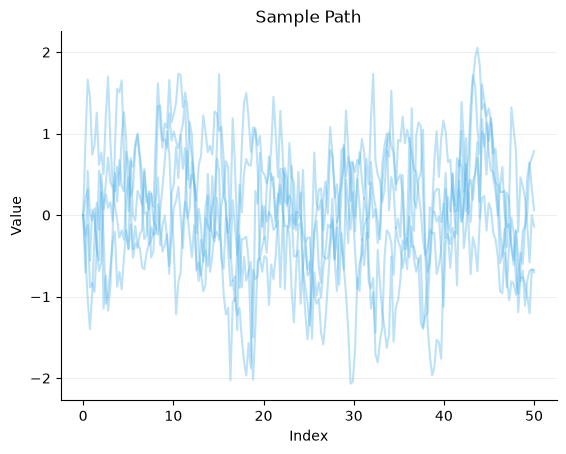

In [3]:
X.sim(5).plot(tmin=0, tmax=50)

## Compare with Brownian motion

This is the same picture without the leash. Brownian motion has no level to return to, so over the same 50 units of time the paths spread much wider and drift off. That gap is the whole point of the Ornstein-Uhlenbeck process.

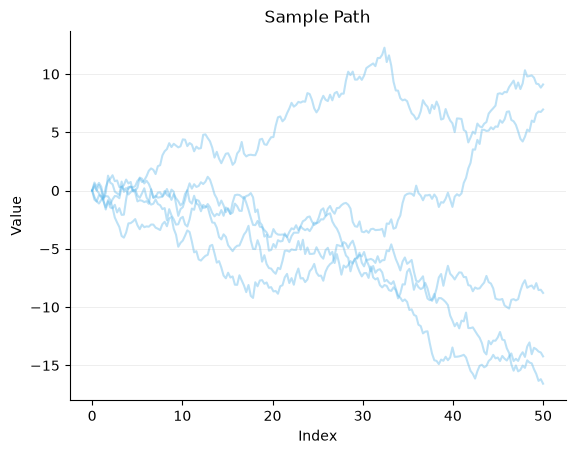

In [4]:
BrownianMotion(scale=1).sim(5).plot(tmin=0, tmax=50)

## Choose the starting value

By default the process starts at 0. Use `initial_value` to start somewhere else -- every path begins exactly there.

In [5]:
Y = OrnsteinUhlenbeck(reversion_rate=1, mean=0, scale=1, initial_value=10)
float(Y.draw()(0))

10.0

Starting far from `mean` shows the pull clearly. All five paths dive from 10 down toward 0, then settle in and wander around it. That first stretch, while the path is still travelling, is called the *transient*.

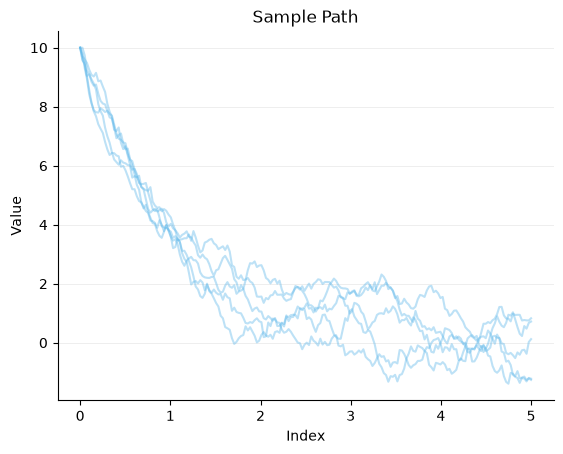

In [6]:
Y.sim(5).plot(tmin=0, tmax=5)

## A stronger pull stays closer to the mean

Raising `reversion_rate` pulls harder, so the paths stay in a tighter band around `mean`. Compare this with the first plot above, which used `reversion_rate=1` over the same time range.

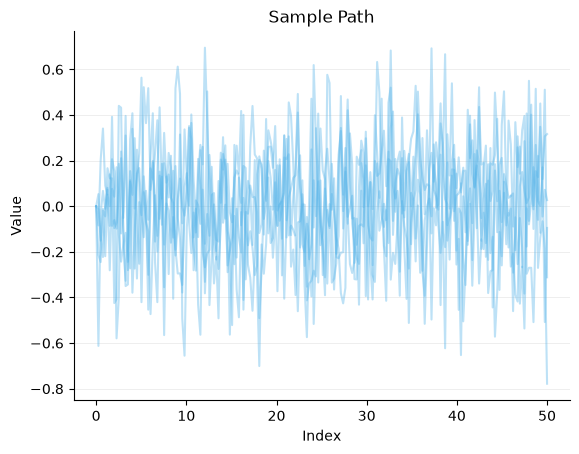

In [7]:
OrnsteinUhlenbeck(reversion_rate=8, scale=1).sim(5).plot(tmin=0, tmax=50)

## Start from the long-run distribution

Left alone, the process settles into a steady pattern: its values follow `Normal(mean, sd=sqrt(scale**2 / (2 * reversion_rate)))`. Passing `initial_value="stationary"` starts every path from that distribution, so there is no transient -- the paths look the same from time 0 as they do later on. Note they no longer all start at the same place.

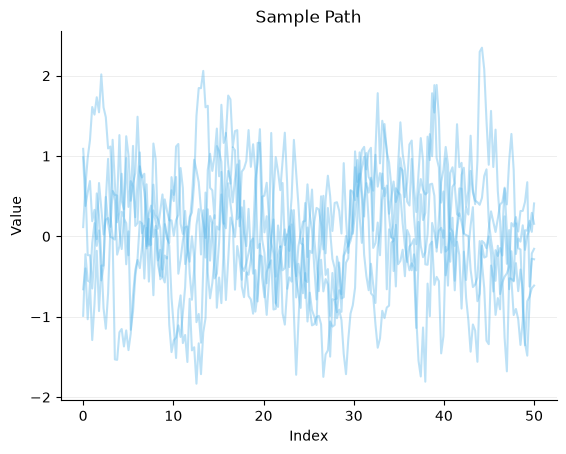

In [8]:
Z = OrnsteinUhlenbeck(reversion_rate=1, mean=0, scale=1, initial_value="stationary")
Z.sim(5).plot(tmin=0, tmax=50)

## The value at a fixed time

The value at a particular time is itself a random variable. Index the process at a time, `X[t]`, to get it -- then simulate, plot, or summarize it like any other random variable. Here `X` started at 0, so by time 3 it has spread out to roughly its long-run spread.

Currently Showing: Histogram (Default)
Alternative Plots: Rug Plot (type = "rug"), Density Plot (type = "density"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


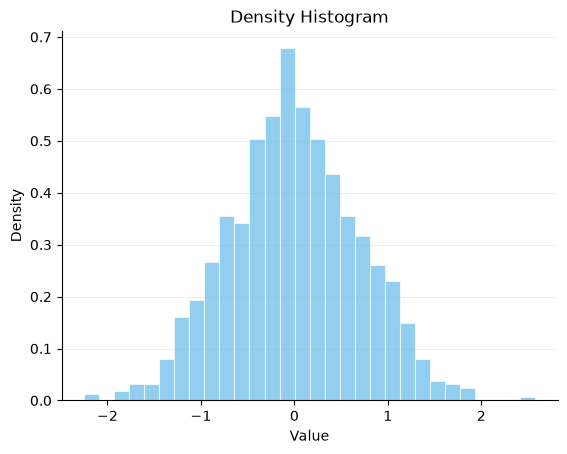

In [9]:
X[3.0].sim(1000).plot()

Its mean is close to 0 (the level it is pulled to) and its variance is close to the long-run value `scale**2 / (2 * reversion_rate)` = `1 / 2` = 0.5.

In [10]:
values = X[3.0].sim(1000)
values.mean(), values.var()

(-0.019598032858317085, 0.513850438070993)